<a href="https://colab.research.google.com/github/fabriciothiengo/REATORES/blob/main/m%C3%A9todo_diferencial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**AJUSTE DE DADOS CINÉTICOS A PARTIR DO MÉTODO DIFERENCIAL**

Para um experimento conduzido em batelada em um vaso rígido, o balanço de massa será:

$$
\frac{dC_A}{dt}=-kCA^n
$$

Aplicando logarítimo em ambos os lados da expressão, chega-se a expressão linear:

$$
ln\left(-\frac{dC_A}{dt}\right) = n \cdot lnC_A + lnk
$$

Para os dados experimentais a seguir, existem 2 maneiras de ajustar os parâmetros cinéticos a partir do método diferencial

In [2]:
import numpy as np
t=np.linspace(0,8,9)
C=np.array([10,8.87,7.87,6.98,6.19,5.49,4.87,4.32,3.82])

**OPÇÃO 1** Esta não é propriamente a aplicação do método, mas uma forma alternativa para quem não quer calcular derivadas. Consiste em ajustar um polinômio com os dados de concentração e derivar o polinômio para obter justamente uma expressão para dC/dt, o que evita o cálculo numérico da derivada

ORDEM = 0.98
k = 0.13


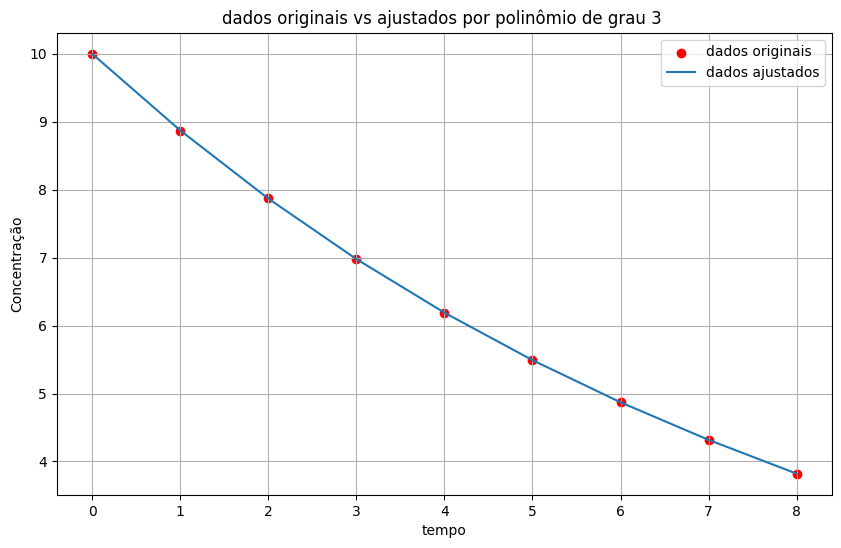

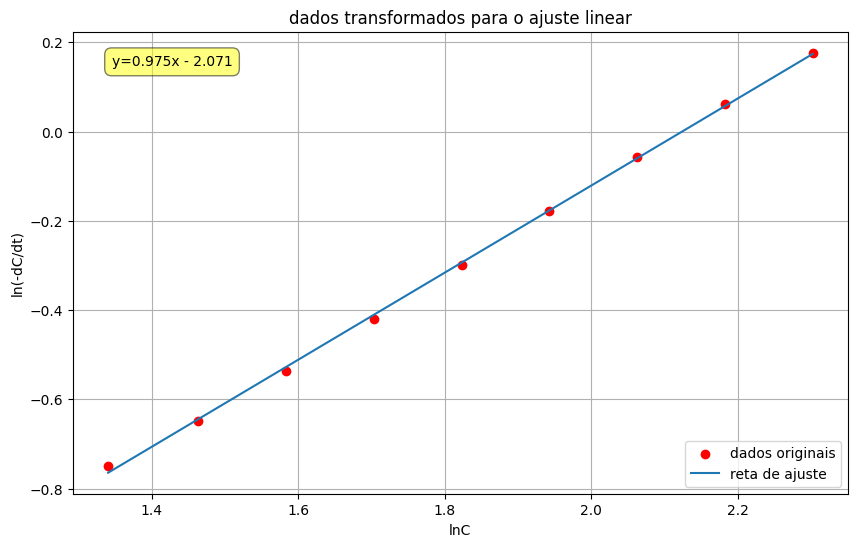

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Ajustando o polinômio para os dados de C versus t
grau = 3
coef = np.polyfit(t, C, grau)

# Criando o polinômio a partir dos coeficientes
poli_C = np.poly1d(coef)

# Calculando os valores pelo polinômio ajustado
C_fit = poli_C(t)

# Calculando a derivada do polinômio
d_poli_C = poli_C.deriv()

# Calculando os valores de dCdt
dC_dt_fit = d_poli_C(t)

#gráfico dos valores originais e dos valores previstos pelo polinômio ajustado
plt.figure(figsize=(10, 6))
plt.scatter(t, C, color='red', label='dados originais')
plt.plot(t, C_fit, label='dados ajustados')
plt.xlabel('tempo')
plt.ylabel('Concentração')
plt.title(f'dados originais vs ajustados por polinômio de grau {grau} ')
plt.legend()
plt.grid(True)

#ajustando os dados para obter os parâmetros cinéticos
lnC=np.log(C)
lndC=np.log(-dC_dt_fit)

#ajustando a reta com os dados
coef_lin=np.polyfit(lnC,lndC,1)
poli_lin=np.poly1d(coef_lin)
lndC_fit_lin=poli_lin(lnC)

#grafico com os dados para o ajuste
plt.figure(figsize=(10, 6))
plt.scatter(lnC, lndC, color='red', label='dados originais')
plt.plot(lnC, lndC_fit_lin, label='reta de ajuste')
plt.xlabel('lnC')
plt.ylabel('ln(-dC/dt)')
plt.title(f'dados transformados para o ajuste linear')
plt.legend()
plt.grid(True)

# mostra a equação de ajuste no gráfico
m = coef_lin[0]
b = coef_lin[1]
eq_text = f'y={m:.3f}x {'+' if b >= 0 else '-'} {abs(b):.3f}'
plt.text(0.05, 0.95, eq_text, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

print(f'ORDEM = {m:.2f}')
print(f'k = {np.exp(b):.2f}')


**OPÇÃO 2: Derivada Numérica por Diferenças Finitas**

Utilizar diferenças finitas para calcular a derivada numérica $\frac{dC}{dt}$.  
Neste caso, aplicamos:

- Diferença progressiva para o primeiro ponto  
- Diferença central para os pontos intermediários  
- Diferença regressiva para o último ponto  

### 🔹 Diferença Progressiva
Usada geralmente no primeiro ponto de dados:

$$
\frac{dC}{dt} \approx \frac{C_{i+1} - C_i}{t_{i+1} - t_i}
$$

---

### 🔹 Diferença Central
Mais precisa, utilizada nos pontos intermediários:

$$
\frac{dC}{dt} \approx \frac{C_{i+1} - C_{i-1}}{t_{i+1} - t_{i-1}}
$$

---

### 🔹 Diferença Regressiva
Usada geralmente no último ponto de dados:

$$
\frac{dC}{dt} \approx \frac{C_i - C_{i-1}}{t_i - t_{i-1}}
$$

In [31]:
# Vetor para armazenar as derivadas
dCdt = np.zeros_like(C)

# Diferença progressiva (primeiro ponto)
dCdt[0] = (C[1] - C[0]) / (t[1] - t[0])

# Diferença central (pontos intermediários)
for i in range(1, len(C) - 1):
    dCdt[i] = (C[i+1] - C[i-1]) / (t[i+1] - t[i-1])

# Diferença regressiva (último ponto)
dCdt[-1] = (C[-1] - C[-2]) / (t[-1] - t[-2])


lndCdt = np.log(-dCdt)

# Regressão linear
coef = np.polyfit(lnC, lndCdt, 1)

n = coef[0]
lnk = coef[1]
k = np.exp(lnk)

print(f"ORDEM: {n:.2f}")
print(f"k: {k:.2f}")

ORDEM: 0.91
k: 0.14
